# Preprocessing: clustering demo

Notebook này minh hoạ một quy trình phân nhóm (clustering) các chuỗi thời gian nhằm phục vụ việc lựa chọn mô hình và chiến lược huấn luyện (local vs global, deterministic vs probabilistic).

Ý tưởng chính là **biểu diễn mỗi chuỗi thời gian bằng một vector feature**, sau đó phân cụm trong không gian feature để nhóm các series có đặc tính tương đồng. Cách tiếp cận “feature-based time-series analysis” đã được chứng minh hiệu quả trong phân tích tổng quát, trực quan hoá instance space và hỗ trợ lựa chọn mô hình dự báo [1][2][3].


## Mục tiêu chính

**Nhóm các series có đặc tính giống nhau để có thể fit chung một mô hình hiệu quả và có ý nghĩa.**

Các cluster được dùng để:

* Quyết định local vs global model
* Gợi ý model family phù hợp (structural vs probabilistic vs robust)
* Giải thích vì sao các series nên / không nên fit chung

Cách tiếp cận này phù hợp với hướng “meta-learning for forecasting”, trong đó features của chuỗi thời gian được dùng để mô tả đặc tính và dự đoán hành vi thuật toán [2][3]


# 1. Feature Bank Extraction

Mỗi chuỗi thời gian được biểu diễn bằng một **feature bank** mô tả các khía cạnh khác nhau của dữ liệu. Feature bank không chỉ phục vụ clustering mà còn phục vụ “diagnosis” để chỉ ra vì sao series khó (hard) và cần xử lý khác nhau.

Tư duy feature-based này tương đồng với các framework tổng quan như hctsa [4] và feature-based instance space trong forecasting [5], trong đó chuỗi thời gian được ánh xạ sang vector feature để phân tích phân nhóm và tìm feature có khả năng phân biệt.

### (a) Data quality / validity

**missing_ratio, constant_ratio, n_obs**

* Mục tiêu: phát hiện chuỗi thiếu dữ liệu, không đủ quan sát hoặc gần như không biến động.
* Hành động: cảnh báo/loại trừ sớm hoặc xử lý đặc thù trước khi fit model.

Các feature nhóm này chủ yếu đóng vai trò gating/validity check, tránh việc clustering bị nhiễu bởi series “không đủ tín hiệu”.


### (b) Distribution / demand pattern (chỉ áp dụng khi zero-value có ý nghĩa)

**zero_ratio, ADI, CV², demand_type**

Nhóm feature này nhằm mô tả intermittent / zero-inflated demand, vốn thường không có structure theo nghĩa trend/seasonality. Taxonomy dựa trên ADI và CV² là một cách phân loại chuẩn trong intermittent demand forecasting [6], và được sử dụng rộng rãi để định hướng lựa chọn mô hình phù hợp [7].

* ADI (Average Demand Interval) đo mức độ gián đoạn giữa các lần demand > 0
* CV² đo mức độ biến thiên của positive demand


### (c) Structural / temporal shape

**trend_strength, seasonality_strength, acf1, acf_seasonal**

Nhóm feature này mô tả “độ mạnh cấu trúc” của chuỗi thời gian, đóng vai trò nền tảng để định nghĩa similarity giữa các series trong clustering.

* Strength of trend/seasonality được định nghĩa từ STL decomposition theo variance ratio [8].
* ACF lag 1 và seasonal lag phản ánh mức độ persistence và seasonal correlation.

Nhóm feature này đóng vai trò trọng tâm vì nó liên quan trực tiếp đến việc series có thể “chia sẻ mô hình” hay không.


### (d) Drift / regime change

**stability, lumpiness**

Nhóm feature này nhằm phát hiện nonstationarity/regime change theo thời gian.
Trong thực hành forecasting, các series có thay đổi chế độ thường yêu cầu rolling training, adaptation hoặc segmentation. Cơ sở lý thuyết của việc quan tâm đến structural break/regime change được tổng hợp trong review về change point detection [10].


### (e) Event / shock

**spike_strength, anomaly_ratio**

Nhóm feature này nhằm phát hiện series bị chi phối bởi event, shock hoặc outlier.
Các hiện tượng anomaly/spike trong time series là một chủ đề lớn và có thể làm sai lệch việc huấn luyện nếu không xử lý robust [11].


Hai nhóm feature về regime change và shock cũng đóng vai trò quan trọng trong phương pháp chỉ ra các chuỗi thời gian bất thường trong một tập chuỗi lớn [9] 


### (f) Complexity / intrinsic predictability

**spectral_entropy, WPE**

Nhóm feature này đo mức độ “intrinsic unpredictability” của chuỗi, nhằm cảnh báo các series không nên kỳ vọng accuracy cao do cấu trúc nội tại yếu hoặc quá phức tạp.

* Weighted Permutation Entropy (WPE) là thước đo complexity có xét biên độ, hữu ích để đánh giá độ ngẫu nhiên/khó dự báo [12][13] Các thước đo entropy được tổng hợp trong survey của Mihailović gần đây và nhấn mạnh vai trò trong đo lường complexity/predictability của time series [14].


## Mapping feature → hard type → action (decision-ready)

| Hard type                       | Câu hỏi chính                 | Feature                       | Hành động                                          |
| ------------------------------- | ----------------------------- | ----------------------------- | -------------------------------------------------- |
| Distribution-dominated (Type C) | Zero/intermittent demand?     | ADI, CV², zero_ratio          | Probabilistic / intermittent methods               |
| Intrinsic unpredictability      | Có structure đủ mạnh không?   | spectral_entropy, WPE         | Cảnh báo low predictability, ceiling accuracy thấp |
| Drift / regime change           | Có đổi chế độ theo thời gian? | stability, lumpiness          | Rolling / adaptive / segmentation                  |
| Event / spike                   | Có shock/outlier dominance?   | spike_strength, anomaly_ratio | Robust training + outlier handling                 |


# 2. (Optional) Detect Distribution-Dominated Series (Type C)

Trước khi clustering theo structure, notebook tách riêng Type C - các series mà hành vi chủ yếu bị chi phối bởi phân bố (intermittent, zero-inflated demand). Việc dùng ADI và CV² để phân loại demand pattern có nền tảng trong intermittent demand forecasting [6][7].

**Lý do tách sớm**

* Type C thường có trend/season/ACF yếu → clustering theo shape/structure ít ý nghĩa
* Tối ưu hơn nếu route thẳng sang nhóm mô hình probabilistic / intermittent (Croston family, SBA variants)

Trong demo:

* Type C được phát hiện bằng ADI + CV² (tham khảo thêm threshold theo Janssen, thesis [15])
* Các bước PCA & clustering chỉ áp dụng cho **non-C**
* Type C được profile theo demand type (intermittent vs lumpy)


# 3. PCA for Insight & Feature Selection

PCA được dùng nhằm:

* Giảm tương quan giữa feature
* Hiểu feature nào thực sự phân hoá dữ liệu
* Tránh clustering bị chi phối bởi noise / heavy tail


**Quy trình**

* Log-transform các feature heavy-tailed (spike, anomaly, lumpiness…)
* Standardize
* Fit PCA trên non-C
* Chọn số PC giải thích ~80–90% variance
* Phân tích loadings/squared loadings để chọn subset feature phù hợp cho similarity clustering

**Lưu ý về skew/kurtosis**
Một số feature distributional như skewness/kurtosis có thể không được đưa trực tiếp vào similarity clustering mà dùng như:

* kiểm tra heavy tail / outlier dominance
* quyết định log-transform hoặc robust scaling
  (đây là bước tiền xử lý để tránh feature heavy-tailed chi phối PCA/KMeans).


# 4. Clustering Strategy

Notebook thử hai chiến lược:

### (a) Clustering trên PCA embeddings

Phù hợp khi:

* nhiều feature
* cần giảm chiều mạnh

Ưu điểm: compact, orthogonal
Nhược điểm: dễ bị dominant PC chi phối nếu PC đó không đúng “similarity semantics”.

### (b) Clustering trực tiếp trên subset feature (recommended trong demo)

Nếu PCA cho thấy:

* chỉ 1–2 trục chính mang ý nghĩa similarity (structure vs entropy)
* các PC còn lại chủ yếu là noise/diagnosis, notebook cluster trực tiếp trên subset feature đó (đã scale).


## Chọn số cụm (k)

Silhouette thường bias về k nhỏ (đặc biệt k=2), nên notebook dùng composite score kết hợp:

* Silhouette (separation)
* Within-cluster dispersion (homogeneity)
* Size imbalance (tránh fragmentation)

Mục tiêu: chọn k nhỏ nhất nhưng cải thiện rõ rệt độ đồng nhất trong cluster, phù hợp với yêu cầu routing (không tạo quá nhiều nhánh model).


# 5. (Optional) DTW refinement inside a small structured cluster

Ngoài Feature-based clustering là phương pháp chính ta dùng để hỗ trợ bước modeling, shape-based clustering cũng được sử dụng rộng rãi [16]. Trong một số cluster có structure mạnh nhưng bị chi phối bởi event/regime timing khác nhau, notebook thử thêm bước refinement theo **DTW**.

DTW (Dynamic Time Warping) là một distance measure phổ biến trong shape-based clustering, cho phép so sánh chuỗi khi có lệch pha hoặc lệch thời điểm [17]. Bước này được dùng cục bộ trên cluster nhỏ nhằm:

* kiểm tra giả thuyết cluster đang chứa nhiều regime timing
* tách nhóm “early-onset vs late-onset” (theo thực nghiệm demo)

Do chi phí cao và kém ổn định trên các nhóm series heterogeneous hoặc weakly structured, ta chỉ dùng DTW như “regime flag” trên cụm đã có đặc tính chung, không thay thế feature clustering.


**References**

[1] https://arxiv.org/pdf/1709.08055

[2] https://www.sciencedirect.com/science/article/abs/pii/S0169207016301030

[3] https://www.robjhyndman.com/papers/fforms.pdf

[4] https://github.com/benfulcher/hctsa

[5] https://github.com/Nixtla/tsfeatures

[6] https://doi.org/10.1016/j.ijforecast.2004.10.001

[7] https://doi.org/10.1007/s12046-020-1285-8

[8] https://otexts.com/fpp2/seasonal-strength.html

[9] https://robjhyndman.com/papers/icdm2015.pdf

[10] https://arxiv.org/pdf/1801.00718

[11] https://arxiv.org/pdf/2002.04236

[12] https://doi.org/10.1103/physreve.87.022911

[13] https://pubmed.ncbi.nlm.nih.gov/25493861/

[14] https://pubmed.ncbi.nlm.nih.gov/40566185/

[15] https://pure.tue.nl/ws/portalfiles/portal/230369575/Master_Thesis_Iris_Janssen.pdf

[16] https://www.sciencedirect.com/science/article/abs/pii/S0306437915000733

[17] https://rstudio-pubs-static.s3.amazonaws.com/474160_0761428e8683401e941a92a4177254a4.html

## Import & Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import entropy, skew, kurtosis
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
import ordpy
import antropy as ant

In [2]:
pd.set_option("display.max_columns", 20)

RANDOM_STATE = 42
SEASONAL_PERIOD = 7

In [337]:
data_path = "m5_preprocess_data.csv"
df = pd.read_csv(data_path, parse_dates=["date"])
df = df.set_index("date").sort_index()
df.head()

,FOODS_1_001,FOODS_1_002,FOODS_1_003,FOODS_1_004,FOODS_1_005,FOODS_1_006,FOODS_1_008,FOODS_1_009,FOODS_1_010,FOODS_1_011,...,HOUSEHOLD_2_507,HOUSEHOLD_2_508,HOUSEHOLD_2_509,HOUSEHOLD_2_510,HOUSEHOLD_2_511,HOUSEHOLD_2_512,HOUSEHOLD_2_513,HOUSEHOLD_2_514,HOUSEHOLD_2_515,HOUSEHOLD_2_516
date,,,,,,,,,,,,,,,,,,,,,
2013-08-27,0,0,1,4,1,3,0,0,0,1,...,0,0,0,1,0,0,1,0,0,0
2013-08-28,0,0,1,8,2,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
2013-08-29,0,0,0,11,3,0,0,4,0,3,...,1,0,0,2,0,0,1,0,0,0
2013-08-30,1,0,1,16,3,4,0,1,0,3,...,1,0,0,0,0,0,0,0,0,0
2013-08-31,0,0,2,10,3,3,0,0,0,0,...,1,1,2,3,0,4,0,0,0,0


## Note:

The data used in this demo already satisfies minimal time-series validity requirements: valid timestamps, consistent frequency, no missing observations, and all series contain valid numeric values. Some series contain a high proportion of zero values (up to ~98%). These are treated as valid observations (no sales on a given day), not missing data. As most of the series are zero-heavy, we avoid using outlier clipping and compute features directly on the raw series.

## 1. Feature Extraction

In [42]:
def _prepare_1d_array(x: pd.Series, *, tie_precision: int | None = None, jitter: float = 0.0):
    """Return clean 1D np.array for entropy computation."""
    a = x.astype(float).to_numpy()
    a = a[np.isfinite(a)]
    if a.size == 0:
        return a

    # Optional: rounding to reduce tiny float noise and allow tie handling
    if tie_precision is not None:
        a = np.round(a, tie_precision)

    # Optional: tiny jitter to break exact ties (use cautiously; keep tiny)
    if jitter > 0:
        rng = np.random.default_rng(0)
        a = a + rng.normal(0.0, jitter, size=a.shape)

    return a

In [43]:
def _stl_components(series: pd.Series, seasonal_period: int):
    """Seasonal period fixed by frequency for scalable feature extraction; refined later"""
    stl = STL(series, period=seasonal_period, robust=True)
    res = stl.fit()
    return res.trend, res.seasonal, res.resid


def _strength(component: np.ndarray, resid: np.ndarray):
    """For computing trend & seasonal strength"""
    var_resid = np.nanvar(resid)
    var_total = np.nanvar(component + resid)
    if var_total <= 0:
        return 0.0
    return max(0.0, 1 - var_resid / var_total)


def _spectral_entropy(series: pd.Series):
    x = series.values
    if len(x) == 0:
        return np.nan
    x = x - np.nanmean(x)
    spectrum = np.fft.rfft(x)
    psd = np.abs(spectrum) ** 2
    psd_sum = psd.sum()
    if psd_sum == 0:
        return np.nan
    psd /= psd_sum
    se = entropy(psd, base=2)
    max_entropy = np.log2(len(psd)) if len(psd) > 0 else 1
    return se / max_entropy


def _stability_lumpiness(series: pd.Series, width: int):
    windows = [series[i : i + width] for i in range(0, len(series), width)]
    window_means = [w.mean() for w in windows if len(w) == width]
    window_vars = [w.var() for w in windows if len(w) == width]
    stability = np.var(window_means) if window_means else np.nan
    lumpiness = np.var(window_vars) if window_vars else np.nan
    return stability, lumpiness


def _adi_cv2(series: pd.Series):
    events = series > 0
    zero_ratio = 1 - events.mean()
    event_idx = np.flatnonzero(events.values)
    if len(event_idx) > 1:
        adi = np.diff(event_idx).mean()
    else:
        adi = np.inf
    positive = series[series > 0]
    if len(positive) > 1 and positive.mean() > 0:
        cv2 = (positive.std() / positive.mean()) ** 2
    else:
        cv2 = np.inf
    return zero_ratio, adi, cv2


def _acf_at_lag(series: pd.Series, lag: int):
    """Support function to compute acf"""
    x = series.values
    if len(x) <= lag:
        return np.nan
    try:
        acf_vals = acf(x, nlags=lag, fft=True, missing="drop")
        return acf_vals[lag]
    except Exception:
        return np.nan


def _acf_features(series: pd.Series, seasonal_period: int):
    acf1 = _acf_at_lag(series, lag=1)
    acf_seasonal = (
        _acf_at_lag(series, lag=seasonal_period)
        if seasonal_period is not None and seasonal_period > 1
        else np.nan
    )
    return acf1, acf_seasonal


def _spike_strength(resid: np.ndarray, q: float = 0.99):
    """
    Measure spike / shock dominance in residual component.
    High value: rare but strong shocks.
    Low value: smooth residuals.
    """
    resid = resid[np.isfinite(resid)]
    if resid.size < 10:
        return np.nan

    eps = 1e-8
    mad = stats.median_abs_deviation(resid, nan_policy="omit")
    mad = mad if mad > 0 else np.nanmedian(np.abs(resid)) + eps

    spike = np.nanpercentile(np.abs(resid), q * 100) / (mad + eps)
    return float(spike)


def _anomaly_ratio(resid: np.ndarray, z: float = 5.0):
    """Fraction of points that are extreme anomalies in residual"""
    resid = resid[np.isfinite(resid)]
    if resid.size < 10:
        return np.nan

    mad = stats.median_abs_deviation(resid, nan_policy="omit")
    if mad <= 0:
        return 0.0

    zscore = np.abs(resid) / mad
    return float(np.mean(zscore > z))


def _wpe_feature(series: pd.Series,*,dx: int = 5,tau: int = 1,tie_precision: int | None = 0,jitter: float = 0.0):
    """Weighted Permutation Entropy (normalized to [0,1]): intrinsic predictability"""
    a = _prepare_1d_array(series, tie_precision=tie_precision, jitter=jitter)
    if a.size < 50:
        return np.nan

    wpe = ordpy.weighted_permutation_entropy(
        a,
        dx=dx,
        dy=1,
        taux=tau,
        tauy=1,
        base=2,
        normalized=True,
        tie_precision=None,
    )
    return float(wpe)

In [44]:
def compute_features(df_metrics: pd.DataFrame, seasonal_period: int = SEASONAL_PERIOD):
    records = []
    for col in df_metrics.columns:
        series = df_metrics[col].astype(float)
        if series.isna().all():
            continue
        try:
            trend, seasonal, resid = _stl_components(series, seasonal_period)
        except Exception:
            trend = pd.Series(np.zeros_like(series), index=series.index)
            seasonal = pd.Series(np.zeros_like(series), index=series.index)
            resid = series - series.mean()

        trend_strength = _strength(trend.values, resid.values)
        seasonality_strength = _strength(seasonal.values, resid.values)
        spectral_entropy = _spectral_entropy(series)
        stability, lumpiness = _stability_lumpiness(series, width=seasonal_period)
        zero_ratio, adi, cv2 = _adi_cv2(series)
        acf1, acf_seasonal = _acf_features(series, seasonal_period)
        spike_strength = _spike_strength(resid.values)
        anomaly_ratio = _anomaly_ratio(resid.values)
        wpe = _wpe_feature(series)

        records.append(
            {
                "series_id": col,

                # Data quality
                "missing_ratio": series.isna().mean(),
                "constant_ratio": (series.diff().abs().fillna(0) == 0).mean(),

                # Structure
                "trend_strength": trend_strength,
                "seasonality_strength": seasonality_strength,
                "acf1": acf1,
                "acf_seasonal": acf_seasonal,

                # Complexity
                "spectral_entropy": spectral_entropy,
                "wpe": wpe,

                # Drift / regime
                "stability": stability,     # mean-instability
                "lumpiness": lumpiness,     # variance-instability

                # Event / shock
                "spike_strength": spike_strength,
                "anomaly_ratio": anomaly_ratio,

                # Distribution
                "zero_ratio": zero_ratio,
                "adi": adi,
                "cv2": cv2,
            }
        )
    features_df = pd.DataFrame.from_records(records).set_index("series_id")
    return features_df


features_df = compute_features(df)
features_df.head()

,missing_ratio,constant_ratio,trend_strength,seasonality_strength,acf1,acf_seasonal,spectral_entropy,wpe,stability,lumpiness,spike_strength,anomaly_ratio,zero_ratio,adi,cv2
series_id,,,,,,,,,,,,,,,
FOODS_1_001,0.0,0.458,0.037649,0.016085,0.015773,0.016493,0.923285,0.800211,0.213746,1.329443,73.365307,0.341,0.615,2.585938,0.395943
FOODS_1_002,0.0,0.596,0.063236,0.033057,0.060288,0.051445,0.923004,0.731577,0.091037,0.220008,377.705334,0.340,0.723,2.927536,0.217531
FOODS_1_003,0.0,0.401,0.027775,0.105413,0.020850,0.008816,0.932705,0.796891,0.155970,2.135279,15.815924,0.147,0.569,2.323256,0.405212
FOODS_1_004,0.0,0.196,0.569705,0.166487,0.651967,0.436041,0.720678,0.905950,40.763212,2882.143244,17.777316,0.157,0.155,1.183649,0.441693
FOODS_1_005,0.0,0.463,0.209649,0.120612,0.210544,0.177072,0.896675,0.835349,0.838905,49.829205,124.109817,0.377,0.542,2.185996,0.873878


## 2. Detect Distribution-dominant

In [45]:
def classify_demand_adi_cv2(
    features_df: pd.DataFrame,
    adi_col: str = "adi",
    cv2_col: str = "cv2",
    adi_thresh: float = 1.32,
    cv2_thresh: float = 0.49,
):
    df = features_df.copy()

    conditions = [
        (df[adi_col] <= adi_thresh) & (df[cv2_col] <= cv2_thresh),
        (df[adi_col] <= adi_thresh) & (df[cv2_col] > cv2_thresh),
        (df[adi_col] > adi_thresh) & (df[cv2_col] <= cv2_thresh),
        (df[adi_col] > adi_thresh) & (df[cv2_col] > cv2_thresh),
    ]

    choices = ["smooth", "erratic", "intermittent", "lumpy"]

    df["demand_type"] = np.select(conditions, choices, default="unknown")

    return df[["demand_type"]]

In [46]:
demand_type_df = classify_demand_adi_cv2(features_df)

demand_type_df["demand_type"].value_counts()

demand_type
intermittent    2222
lumpy            471
smooth           275
erratic           81
Name: count, dtype: int64

In [47]:
demand_type_df["is_C"] = demand_type_df["demand_type"].isin(
    ["intermittent", "lumpy"]
)

In [242]:
distribution_df = features_df.join(demand_type_df)
distribution_df

,missing_ratio,constant_ratio,trend_strength,seasonality_strength,acf1,acf_seasonal,spectral_entropy,wpe,stability,lumpiness,spike_strength,anomaly_ratio,zero_ratio,adi,cv2,demand_type,is_C
series_id,,,,,,,,,,,,,,,,,
FOODS_1_001,0.0,0.458,0.037649,0.016085,0.015773,0.016493,0.923285,0.800211,0.213746,1.329443,73.365307,0.341,0.615,2.585938,0.395943,intermittent,True
FOODS_1_002,0.0,0.596,0.063236,0.033057,0.060288,0.051445,0.923004,0.731577,0.091037,0.220008,377.705334,0.340,0.723,2.927536,0.217531,intermittent,True
FOODS_1_003,0.0,0.401,0.027775,0.105413,0.020850,0.008816,0.932705,0.796891,0.155970,2.135279,15.815924,0.147,0.569,2.323256,0.405212,intermittent,True
FOODS_1_004,0.0,0.196,0.569705,0.166487,0.651967,0.436041,0.720678,0.905950,40.763212,2882.143244,17.777316,0.157,0.155,1.183649,0.441693,smooth,False
FOODS_1_005,0.0,0.463,0.209649,0.120612,0.210544,0.177072,0.896675,0.835349,0.838905,49.829205,124.109817,0.377,0.542,2.185996,0.873878,lumpy,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HOUSEHOLD_2_512,0.0,0.444,0.036336,0.078417,-0.003845,0.045229,0.932863,0.766031,0.174574,4.000913,25.074339,0.184,0.618,2.606299,0.539731,lumpy,True
HOUSEHOLD_2_513,0.0,0.441,0.234135,0.137828,0.274830,0.259201,0.849645,0.875772,0.535624,2.988780,29.666083,0.210,0.526,2.107822,0.439503,intermittent,True
HOUSEHOLD_2_514,0.0,0.637,0.000000,0.046349,0.028107,-0.001038,0.925613,0.622167,0.030825,0.044351,481.074328,0.313,0.769,4.230435,0.088074,intermittent,True


## 3. PCA

In [135]:
# Features used for PCA 
PCA_FEATURES = [
    # Structure
    "trend_strength",
    "seasonality_strength",
    "acf1",
    "acf_seasonal",

    # Drift / regime
    "stability",
    "lumpiness",

    # Event / shock
    "spike_strength",
    "anomaly_ratio",

    # Complexity
    "spectral_entropy",
    "wpe",
]

In [243]:
# Only non-C series
nonC_df = distribution_df.loc[~distribution_df["is_C"]]

X_nonC = nonC_df[PCA_FEATURES].copy()
X_nonC = X_nonC.dropna(how="any")

### Detect heavy-tailed feature to avoid outliers after scaling

In [246]:
def heavy_tail_diagnostics(df: pd.DataFrame):
    records = []
    for col in df.columns:
        x = df[col].dropna()
        if len(x) < 10:
            continue

        rec = {
            "feature": col,
            "mean": x.mean(),
            "std": x.std(),
            "skewness": skew(x),
            "kurtosis": kurtosis(x, fisher=False),  # >3 = heavy tail
            "p50": x.quantile(0.50),
            "p75": x.quantile(0.75),
            "p90": x.quantile(0.90),
            "p95": x.quantile(0.95),
            "p99": x.quantile(0.99),
        }

        rec["p99_p50_ratio"] = (
            rec["p99"] / rec["p50"] if rec["p50"] > 0 else np.inf
        )
        rec["p99_p75_ratio"] = (
            rec["p99"] / rec["p75"] if rec["p75"] > 0 else np.inf
        )
        rec["iqr"] = rec["p75"] - rec["p50"]

        records.append(rec)

    return pd.DataFrame(records).set_index("feature")

ht_stats = heavy_tail_diagnostics(X_nonC)

In [249]:
def flag_heavy_tailed(
    stats_df: pd.DataFrame,
    skew_th=2.0,
    kurt_th=10.0,
    p99_p50_th=10.0,
):
    flags = []
    for _, r in stats_df.iterrows():
        is_heavy = (
            (abs(r["skewness"]) >= skew_th)
            or (r["kurtosis"] >= kurt_th)
            or (r["p99_p50_ratio"] >= p99_p50_th)
        )
        flags.append(is_heavy)
    out = stats_df.copy()
    out["heavy_tailed"] = flags
    return out

ht_flagged = flag_heavy_tailed(ht_stats)
ht_flagged[ht_flagged["heavy_tailed"] == True]

,mean,std,skewness,kurtosis,p50,p75,p90,p95,p99,p99_p50_ratio,p99_p75_ratio,iqr,heavy_tailed
feature,,,,,,,,,,,,,
seasonality_strength,2.402297e-01,1.150294e-01,2.415598,14.869212,0.226022,0.289301,0.356943,0.406765,6.329373e-01,2.800330e+00,2.187813e+00,0.063279,True
stability,1.620441e+01,1.078316e+02,16.968666,306.147080,2.806493,7.823631,21.338323,57.410456,1.517246e+02,5.406200e+01,1.939312e+01,5.017138,True
lumpiness,3.068557e+04,5.382821e+05,18.774089,353.642482,49.671364,367.341023,3725.234379,9335.862577,4.179392e+04,8.414087e+02,1.137742e+02,317.669659,True
spike_strength,8.877995e+06,1.157205e+08,16.584411,293.116750,11.226580,14.844772,20.669390,42.869148,7.620529e+07,6.787935e+06,5.133477e+06,3.618192,True
anomaly_ratio,1.204579e-01,8.268635e-02,2.828690,11.383095,0.098000,0.132250,0.182000,0.362500,4.900000e-01,5.000000e+00,3.705104e+00,0.034250,True


In [ ]:
# log-transform heavy-tailed features 
for col in ["spike_strength", "anomaly_ratio", "seasonality_strength", "stability", "lumpiness"]:
    if col in X_nonC.columns:
        X_nonC[col] = np.log1p(X_nonC[col])

scaler = StandardScaler()
X_nonC_scaled = scaler.fit_transform(X_nonC)

### PCA results

In [250]:
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_nonC_scaled)

explained_var_nonC = pd.Series(
    pca.explained_variance_ratio_,
    index=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))]
)
explained_var_nonC

PC1     0.515394
PC2     0.163469
PC3     0.123279
PC4     0.080141
PC5     0.064118
PC6     0.029184
PC7     0.013690
PC8     0.004786
PC9     0.003711
PC10    0.002227
dtype: float64

In [251]:
loadings_nonC = pd.DataFrame(
    pca.components_.T,
    index=PCA_FEATURES,
    columns=[f"PC{i+1}" for i in range(len(PCA_FEATURES))],
)

loadings_nonC["PC1_abs"] = loadings_nonC["PC1"].abs()
loadings_nonC.sort_values("PC1_abs", ascending=False)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC1_abs
spectral_entropy,0.410914,0.120909,-0.141114,0.018927,0.039477,-0.249167,0.549610,0.654112,-0.027907,0.043628,0.410914
acf_seasonal,-0.409487,-0.067341,0.205419,0.001531,-0.163957,0.178304,-0.413399,0.735531,-0.120320,-0.023020,0.409487
trend_strength,-0.407884,-0.073797,0.121507,-0.019455,-0.288250,-0.275181,0.413117,-0.140002,-0.587713,-0.344321,0.407884
acf1,-0.401862,0.052366,0.024526,-0.151299,-0.371089,-0.323248,0.205500,0.005976,0.724087,0.059229,0.401862
stability,-0.322249,0.484391,-0.116128,0.242446,0.057012,-0.062121,0.061808,-0.056302,-0.233886,0.721424,0.322249
anomaly_ratio,-0.263057,-0.398144,-0.438417,0.120401,-0.001072,0.620882,0.407366,0.032682,0.076612,0.084826,0.263057
wpe,0.217950,-0.107140,0.214755,0.836705,-0.428981,0.016174,-0.016113,-0.044570,0.089806,-0.015015,0.217950
lumpiness,-0.217286,0.579288,-0.225647,0.311371,0.292991,0.116166,0.003498,0.041202,0.158812,-0.585726,0.217286
spike_strength,-0.206302,-0.469556,-0.324685,0.306286,0.430744,-0.558164,-0.191251,0.059506,0.018764,0.012938,0.206302
seasonality_strength,-0.159022,-0.109397,0.717198,0.110696,0.540467,0.106079,0.327899,0.005656,0.144311,0.066223,0.159022


In [252]:
# Choose number of PCs that explain, e.g., 80–90% variance
cum_var = explained_var_nonC.cumsum()

n_pc = int(np.searchsorted(cum_var.values, 0.85) + 1)
n_pc

4

### Analyze feature contributions

In [253]:
# squared loadings: Feature j đóng góp bao nhiêu vào hướng PC k?
sq = loadings_nonC.drop(columns=["PC1_abs"]).pow(2)

# align EVR to columns: PC k quan trọng đến mức nào trong toàn dataset?
evr = explained_var_nonC[sq.columns]  # Series indexed by PC1..PCn

# Feature j đóng góp bao nhiêu vào tổng variance của dataset thông qua PC k?
global_contrib = sq.mul(evr, axis=1)  # each PC column scaled by its EVR

# Optional: normalize to sum=1 over all cells (for percentage of total explained variance)
global_contrib_pct = global_contrib / global_contrib.values.sum()

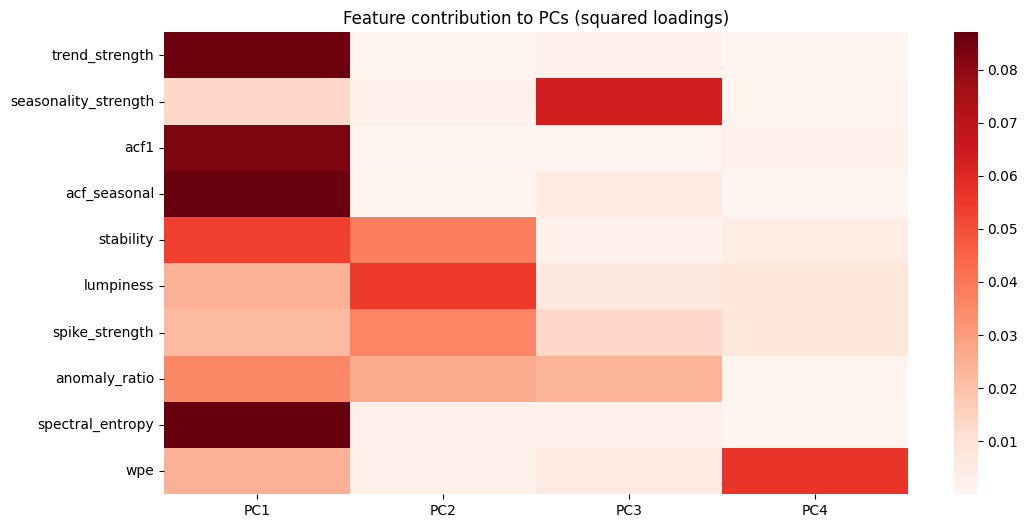

In [254]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    global_contrib_pct.loc[:, ["PC1", "PC2", "PC3", "PC4"]],
    cmap="Reds",
    annot=False,
)
plt.title("Feature contribution to PCs (squared loadings)")
plt.show()

Heatmap global feature contribution (squared loadings × explained variance) cho thấy rõ các trục biến thiên thực sự của dataset:

PC1 (~52% variance) được chi phối chủ yếu bởi
trend_strength, acf1, acf_seasonal và spectral_entropy.
Đây là trục structure vs randomness, phản ánh mức độ pattern ổn định và khả năng dự báo.
→ PC1 là similarity axis chính cho pooling, vì các series có structure tương đồng mới fit chung hiệu quả.

PC3 (~13% variance) gần như hoàn toàn do seasonality_strength chi phối.
Seasonality là nguồn biến thiên độc lập với trend/ACF, và là yếu tố quyết định model family (seasonal vs non-seasonal).
→ Nếu chỉ cluster theo PC1, seasonal và non-seasonal series sẽ bị trộn lẫn; PC3 giúp tách theo hình dạng chu kỳ.

PC2 (16%) tập trung vào lumpiness, spike_strength, instability,
và PC4 (~8%) gần như chỉ là wpe (complexity).
Hai trục này mô tả hành vi nhiễu/độ khó. Hữu dụng cho routing/gating/diagnostic.

Kết luận:
Similarity clustering sẽ được thực hiện trên PC1 + PC3, vì đây là tập trục tối thiểu mô tả shape thực sự của series (structure + seasonality). 

In [255]:
PC_COLUMNS = [f"PC{i+1}" for i in range(n_pc)]

embedding_nonC = pd.DataFrame(
    X_pca[:, :n_pc],
    index=X_nonC.index,
    columns=PC_COLUMNS,
)

embedding_nonC.head()

,PC1,PC2,PC3,PC4
series_id,,,,
FOODS_1_004,-3.868129,1.448192,-0.881581,-0.792496
FOODS_1_012,2.594094,-0.117016,-0.030704,0.236931
FOODS_1_018,-1.453272,1.402753,0.043966,-0.327321
FOODS_1_021,0.690404,0.807396,-2.403618,1.670895
FOODS_1_042,2.292949,0.898972,-2.365775,-1.196189


## 4. Clustering

### On PCA embeddings

In [285]:
def search_k_by_silhouette(X, k_min=2, k_max=10, random_state=42):
    records = []

    for k in range(k_min, k_max + 1):
        model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = model.fit_predict(X)

        sil = silhouette_score(X, labels)
        records.append({"k": k, "silhouette": sil})

    return pd.DataFrame(records)

X_cluster = embedding_nonC

k_search_df = search_k_by_silhouette(X_cluster, k_min=2, k_max=10)
best_k = k_search_df.sort_values("silhouette", ascending=False).iloc[0]["k"]
k_search_df

,k,silhouette
0,2,0.421019
1,3,0.406072
2,4,0.295330
3,5,0.272242
4,6,0.235726
5,7,0.243112
6,8,0.306990
7,9,0.298879
8,10,0.263873


In [286]:
kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_cluster)

l3_df = embedding_nonC.copy()
l3_df["cluster_id"] = cluster_labels

In [260]:
cluster_sizes = l3_df["cluster_id"].value_counts().sort_index()
cluster_sizes

cluster_id
0    255
1    101
Name: count, dtype: int64

In [261]:
def plot_pca_pair(l3_df, pc_x, pc_y):
    plt.figure()
    for cid in sorted(l3_df["cluster_id"].unique()):
        m = l3_df["cluster_id"] == cid
        plt.scatter(
            l3_df.loc[m, pc_x],
            l3_df.loc[m, pc_y],
            s=15,
            label=f"cluster {cid}",
        )
    plt.xlabel(pc_x)
    plt.ylabel(pc_y)
    plt.title(f"Clustering in PCA space ({pc_x} vs {pc_y})")
    plt.legend()
    plt.grid(True)
    plt.show()

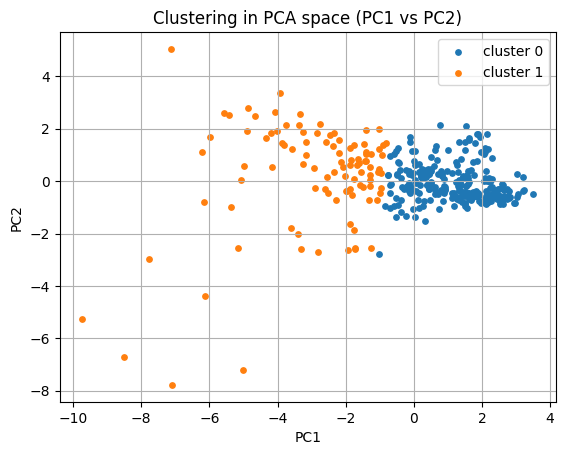

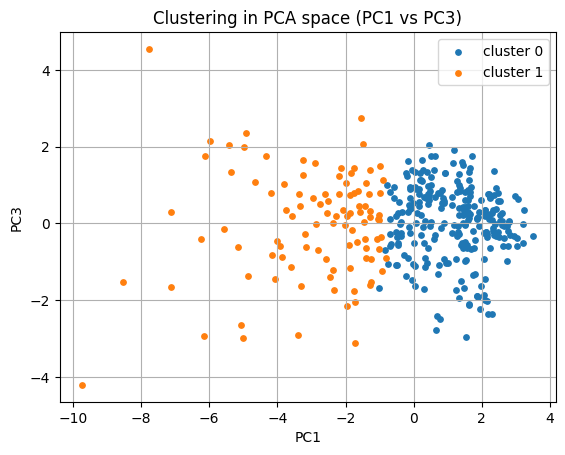

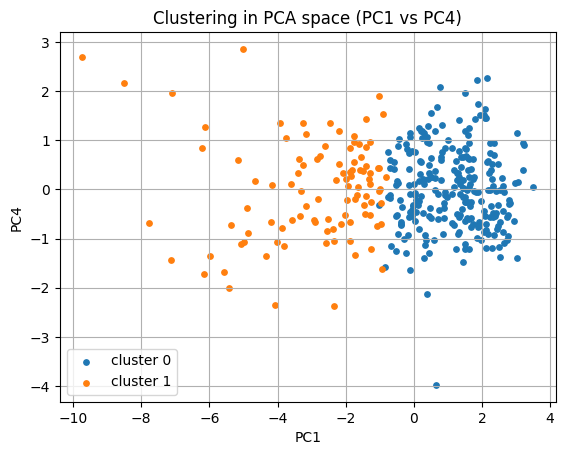

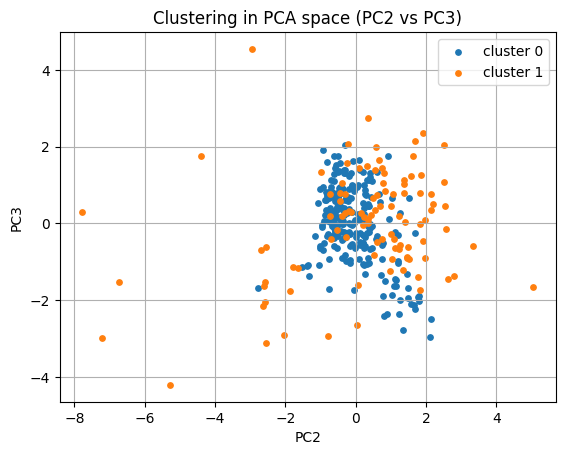

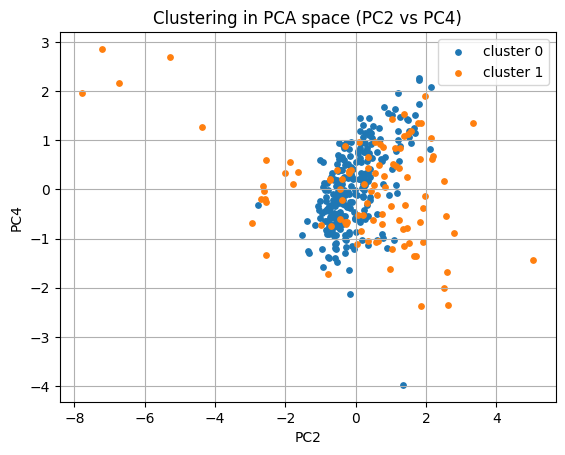

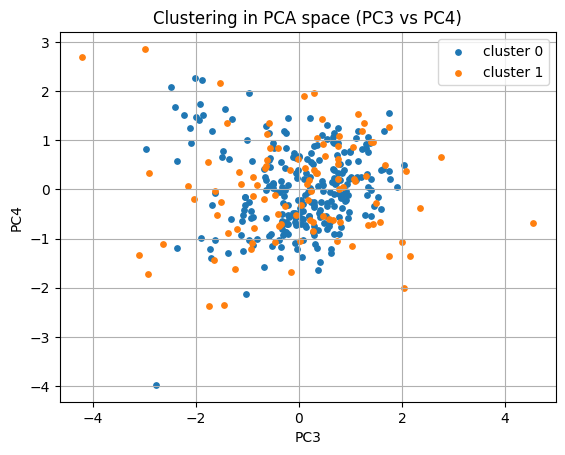

In [288]:
from itertools import combinations

def plot_all_pca_pairs(l3_df, PC_COLUMNS):
    for pc_x, pc_y in combinations(PC_COLUMNS, 2):
        plt.figure()
        for cid in sorted(l3_df["cluster_id"].unique()):
            m = l3_df["cluster_id"] == cid
            plt.scatter(
                l3_df.loc[m, pc_x],
                l3_df.loc[m, pc_y],
                s=15,
                label=f"cluster {cid}",
            )
        plt.xlabel(pc_x)
        plt.ylabel(pc_y)
        plt.title(f"Clustering in PCA space ({pc_x} vs {pc_y})")
        plt.legend()
        plt.grid(True)
        plt.show()

plot_all_pca_pairs(l3_df, PC_COLUMNS)

In [273]:
centroids_pca = (
    l3_df.groupby("cluster_id")[PC_COLUMNS]
    .mean()
    .sort_index()
)

centroids_pca

,PC1,PC2,PC3,PC4
cluster_id,,,,
0,1.160162,-0.078923,0.007120,0.001711
1,-2.929122,0.199261,-0.017977,-0.004321


Khi thực hiện clustering trực tiếp trên **PCA embeddings (PC1–PC4)**, kết quả cho thấy:

* Sự phân tách gần như hoàn toàn diễn ra dọc theo PC1: Hai cluster có centroid khác biệt rõ rệt trên PC1. Trong khi PC2, PC3, PC4 gần như không đóng góp vào việc phân biệt cluster

* Các plot có PC1 cho thấy:

  * ranh giới cluster là một split theo trục PC1
  * các điểm trong từng cluster vẫn chồng chéo mạnh trên PC khác
    
* Các plot không có PC1 cho thấy:

  * không tồn tại separation giữa các cluster
  * hai cluster trộn lẫn hoàn toàn trong các chiều này

Bảng centroid củng cố quan sát trên:

* centroid của hai cluster chỉ khác đáng kể ở PC1
* các thành phần PC còn lại gần như bằng 0 cho cả hai cluster

#### Kết luận

* Clustering trên PCA embeddings trong trường hợp này chỉ tái hiện lại dominant axis (PC1)
* Các PC khác không mang thêm thông tin phân nhóm hữu ích
* Do đó, clustering trong PCA space không khai thác thêm cấu trúc similarity mới

Vì vậy, việc chuyển sang clustering trực tiếp trên các feature gốc đóng góp cho PC1 (trend, ACF, entropy) là hợp lý hơn:

* giữ nguyên semantics của similarity
* tránh PCA rotation artifacts
* và cho kết quả cluster dễ diễn giải hơn cho mục tiêu pooling / fit chung

### On features

In [289]:
# Feature view corresponding to PC1 semantics
PC1_FEATURES = [
    "trend_strength",
    "acf1",
    "acf_seasonal",
    "spectral_entropy",
]

X_feat = nonC_df[PC1_FEATURES].copy()

# Fill NA with median 
X_feat = X_feat.fillna(X_feat.median(numeric_only=True))

scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_feat)

In [275]:
X_cluster_df = pd.DataFrame(
    X_cluster,
    index=X_feat.index,
    columns=PC1_FEATURES,
)

In [277]:
def evaluate_k_feature_clustering(
    X,                 # scaled feature matrix
    X_df,              # same data as DataFrame (for dispersion calc)
    k,
    random_state=42,
):
    model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = model.fit_predict(X)

    # silhouette 
    sil = silhouette_score(X, labels)

    # cluster sizes 
    sizes = pd.Series(labels).value_counts()
    size_imbalance = sizes.std() / sizes.mean()

    # within-cluster dispersion 
    disp = []
    for cid in sizes.index:
        cluster_data = X_df.iloc[labels == cid]
        # mean std across features
        disp.append(cluster_data.std().mean())
    mean_dispersion = np.mean(disp)

    return {
        "k": k,
        "silhouette": sil,
        "mean_dispersion": mean_dispersion,
        "size_imbalance": size_imbalance,
    }

In [278]:
records = []

for k in range(2, 7):  
    rec = evaluate_k_feature_clustering(
        X_cluster,
        X_cluster_df,
        k,
    )
    records.append(rec)

k_eval_df = pd.DataFrame(records)
k_eval_df

,k,silhouette,mean_dispersion,size_imbalance
0,2,0.528201,0.645109,0.444921
1,3,0.446794,0.512617,0.381019
2,4,0.419390,0.490527,0.595046
3,5,0.378291,0.431398,0.500067
4,6,0.337389,0.394256,0.468850


In [279]:
# Normalize metrics
df = k_eval_df.copy()

df["sil_norm"] = (df["silhouette"] - df["silhouette"].min()) / (
    df["silhouette"].max() - df["silhouette"].min()
)

df["disp_norm"] = (df["mean_dispersion"] - df["mean_dispersion"].min()) / (
    df["mean_dispersion"].max() - df["mean_dispersion"].min()
)

df["size_norm"] = (df["size_imbalance"] - df["size_imbalance"].min()) / (
    df["size_imbalance"].max() - df["size_imbalance"].min()
)

# Composite score: reward separation, penalize dispersion & imbalance
df["score"] = (
    df["sil_norm"]
    - 0.6 * df["disp_norm"]
    - 0.4 * df["size_norm"]
)

df.sort_values("score", ascending=False)

,k,silhouette,mean_dispersion,size_imbalance,sil_norm,disp_norm,size_norm,score
1,3,0.446794,0.512617,0.381019,0.573364,0.471834,0.000000,0.290263
0,2,0.528201,0.645109,0.444921,1.000000,1.000000,0.298569,0.280572
3,5,0.378291,0.431398,0.500067,0.214354,0.148062,0.556228,-0.096975
4,6,0.337389,0.394256,0.468850,0.000000,0.000000,0.410374,-0.164150
2,4,0.419390,0.490527,0.595046,0.429745,0.383775,1.000000,-0.200520


In [290]:
# Cluster
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_cluster)

l3_df = X_cluster_df.copy()
l3_df["cluster_id"] = labels

cluster_sizes = l3_df["cluster_id"].value_counts().sort_index()
cluster_sizes

cluster_id
0    138
1     67
2    151
Name: count, dtype: int64

In [292]:
l3_df

,trend_strength,acf1,acf_seasonal,spectral_entropy,cluster_id
series_id,,,,,
FOODS_1_004,1.561785,1.958004,1.175458,-1.645883,1
FOODS_1_012,-0.929813,-1.215058,-1.119596,1.104150,2
FOODS_1_018,0.333634,0.971421,0.387474,-0.393616,0
FOODS_1_021,-0.779149,-1.084009,-0.945613,0.387855,2
FOODS_1_042,-1.541818,-1.412959,-1.772174,1.049648,2
...,...,...,...,...,...
HOUSEHOLD_1_536,0.165255,0.247595,0.579434,-0.504203,0
HOUSEHOLD_1_538,-0.846698,-0.997303,-0.745446,0.509760,2
HOUSEHOLD_1_539,-1.411864,-1.778768,-1.599845,1.106192,2


In [281]:
profile = (
    nonC_df.loc[l3_df.index, PC1_FEATURES]
    .assign(cluster_id=l3_df["cluster_id"])
    .groupby("cluster_id")
    .mean()
)

profile

,trend_strength,acf1,acf_seasonal,spectral_entropy
cluster_id,,,,
0,0.333988,0.339164,0.287822,0.839241
1,0.565020,0.553789,0.491886,0.725938
2,0.152219,0.109260,0.125169,0.901268


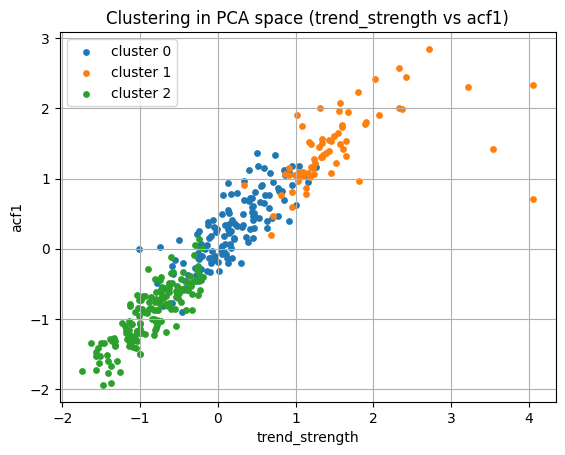

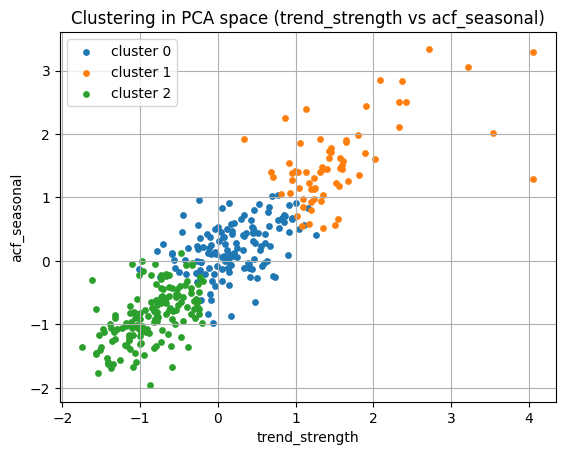

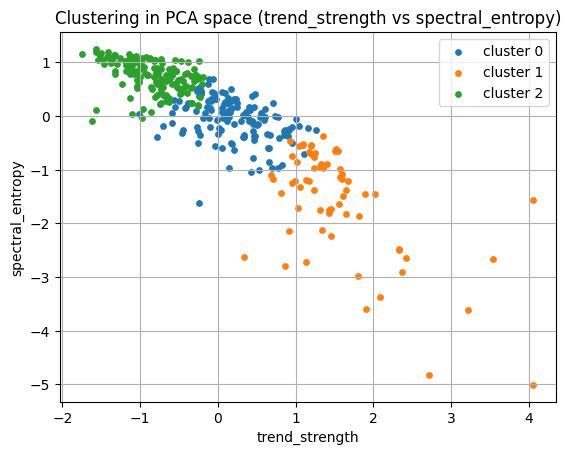

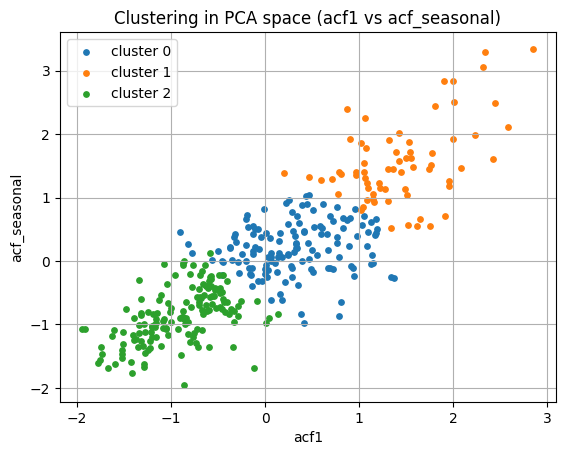

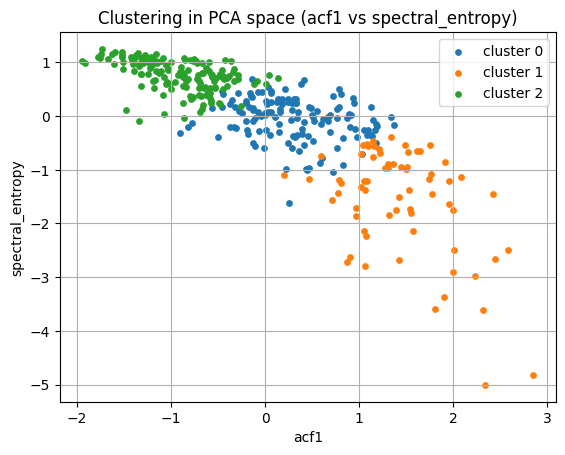

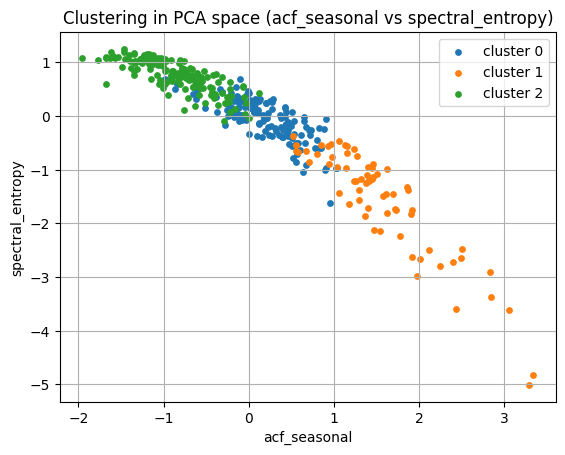

In [291]:
plot_all_pca_pairs(l3_df, PC1_FEATURES)

Khi thực hiện clustering trực tiếp trên các feature đóng góp chính cho PC1
(`trend_strength`, `acf1`, `acf_seasonal`, `spectral_entropy`), kết quả cho thấy ba cluster được phân tách rõ ràng theo mức độ temporal structure.

* **Cluster 1** có giá trị trend_strength và autocorrelation (acf1, acf_seasonal) cao nhất, đồng thời spectral_entropy thấp nhất, phản ánh các series có cấu trúc mạnh và ổn định.
* **Cluster 0** nằm ở mức trung gian trên cả trend, autocorrelation và entropy, đại diện cho các series có cấu trúc vừa phải.
* **Cluster 2** có trend_strength và autocorrelation thấp nhất, trong khi spectral_entropy cao nhất, tương ứng với các series ít cấu trúc và tính ngẫu nhiên cao hơn.

Các feature phân hoá chính là trend_strength và acf1, trong khi `acf_seasonal` và `spectral_entropy` đóng vai trò hỗ trợ và củng cố ranh giới giữa các cluster.

## Profile

In [293]:
# Merge cluster labels into distribution_df
merged_df = distribution_df.merge(
    l3_df[["cluster_id"]],
    left_index=True,
    right_index=True,
    how="left",
)

def build_group_label(row):
    if row["is_C"]:
        return f"type_C_{row['demand_type']}"
    else:
        return f"struct_cluster_{int(row['cluster_id'])}"

merged_df["group_label"] = merged_df.apply(build_group_label, axis=1)

In [317]:
summary_df = (
    merged_df
    .groupby("group_label")
    .agg(
        # size 
        size=("group_label", "size"),

        # structural mean 
        trend_mean=("trend_strength", "mean"),
        acf1_mean=("acf1", "mean"),
        acf_seasonal_mean=("acf_seasonal", "mean"),
        entropy_mean=("spectral_entropy", "mean"),

        # structural dispersion (homogeneity)
        trend_std=("trend_strength", "std"),
        acf1_std=("acf1", "std"),
        acf_seasonal_std=("acf_seasonal", "std"),
        entropy_std=("spectral_entropy", "std"),

        # distribution / hardness 
        zero_ratio=("zero_ratio", "mean"),
        adi=("adi", "mean"),
        cv2=("cv2", "mean"),
        spike_strength=("spike_strength", "mean"),
        stability=("stability", "mean"),   
        lumpiness=("lumpiness", "mean"),
        anomaly_ratio=("anomaly_ratio", "mean"), 
    )
    .sort_values("size", ascending=False)
)

summary_df

,size,trend_mean,acf1_mean,acf_seasonal_mean,entropy_mean,trend_std,acf1_std,acf_seasonal_std,entropy_std,zero_ratio,adi,cv2,spike_strength,stability,lumpiness,anomaly_ratio
group_label,,,,,,,,,,,,,,,,
type_C_intermittent,2222,0.167932,0.150767,0.138394,0.891780,0.191423,0.147845,0.131161,0.054733,0.655289,4.016845,0.296013,8.076919e+06,0.771701,14.570437,0.319958
type_C_lumpy,471,0.227928,0.226995,0.185672,0.875147,0.206293,0.196770,0.153880,0.065910,0.552450,2.554128,0.749061,1.216298e+07,5.200636,2851.865152,0.295858
struct_cluster_2,151,0.152219,0.109260,0.125169,0.901268,0.064220,0.080044,0.064961,0.021982,0.158914,1.192636,0.457843,1.145048e+01,2.687638,1210.146923,0.090609
struct_cluster_0,138,0.333988,0.339164,0.287822,0.839241,0.076951,0.092672,0.061637,0.029892,0.155196,1.159788,0.406901,1.826194e+01,6.535447,501.465075,0.118957
struct_cluster_1,67,0.565020,0.553789,0.491886,0.725938,0.122765,0.100279,0.097864,0.075764,0.205478,1.150368,0.434797,4.717257e+07,66.582759,159285.524578,0.190821


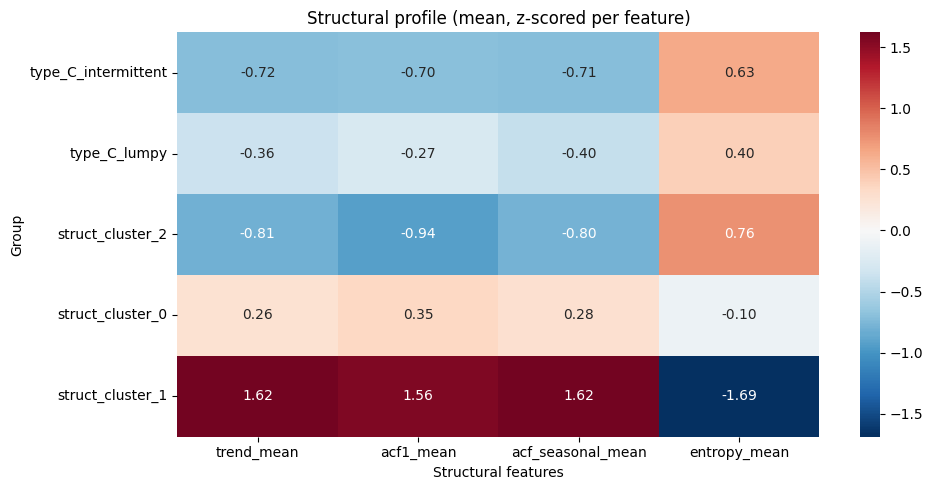

In [306]:
STRUCT_MEAN_COLS = [
    "trend_mean",
    "acf1_mean",
    "acf_seasonal_mean",
    "entropy_mean",
]

struct_mean = summary_df[STRUCT_MEAN_COLS]

# Normalize per feature (column-wise z-score)
struct_mean_z = (struct_mean - struct_mean.mean()) / struct_mean.std()

plt.figure(figsize=(10, 5))
sns.heatmap(
    struct_mean_z,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)
plt.title("Structural profile (mean, z-scored per feature)")
plt.ylabel("Group")
plt.xlabel("Structural features")
plt.tight_layout()
plt.show()

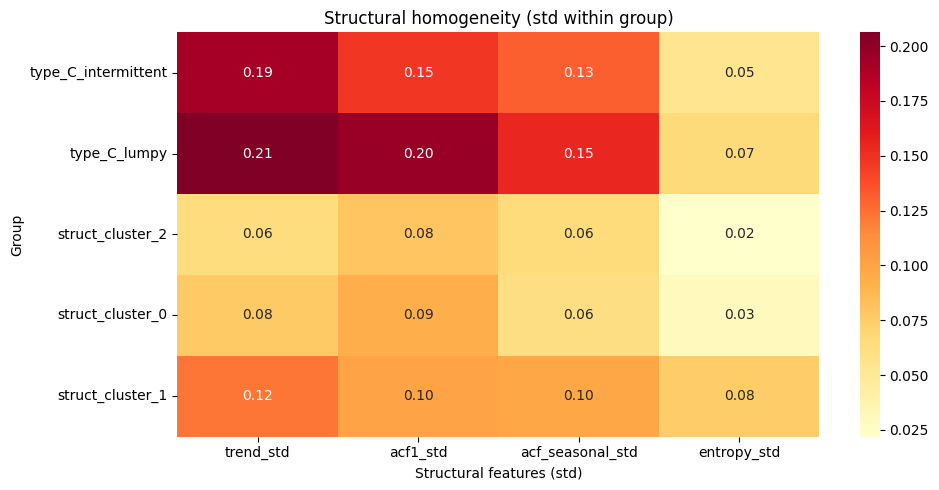

In [307]:
STRUCT_STD_COLS = [
    "trend_std",
    "acf1_std",
    "acf_seasonal_std",
    "entropy_std",
]

struct_std = summary_df[STRUCT_STD_COLS]

plt.figure(figsize=(10, 5))
sns.heatmap(
    struct_std,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)
plt.title("Structural homogeneity (std within group)")
plt.ylabel("Group")
plt.xlabel("Structural features (std)")
plt.tight_layout()
plt.show()

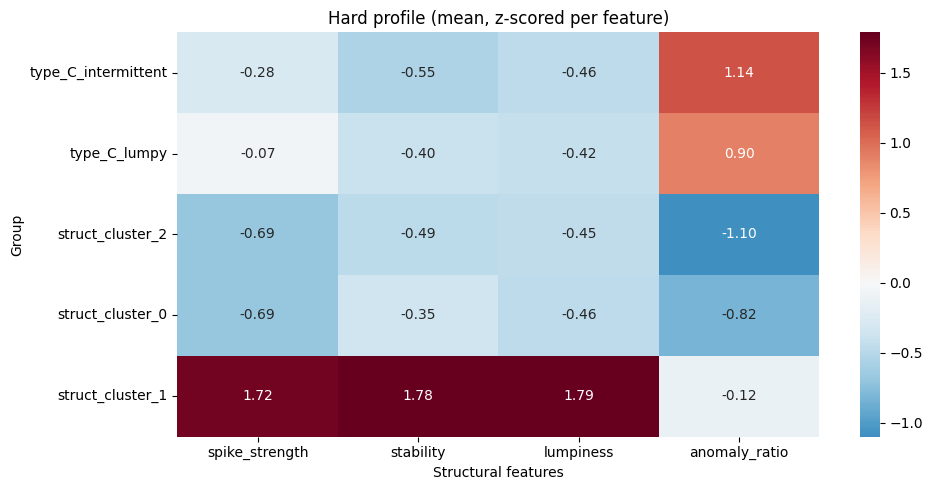

In [315]:
HARD_MEAN_COLS = [
     "spike_strength",
     "stability",  
     "lumpiness",
     "anomaly_ratio",
]

hard_mean = summary_df[HARD_MEAN_COLS]

# Normalize per feature (column-wise z-score)
hard_mean_z = (hard_mean - hard_mean.mean()) / hard_mean.std()

plt.figure(figsize=(10, 5))
sns.heatmap(
    hard_mean_z,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)
plt.title("Hard profile (mean, z-scored per feature)")
plt.ylabel("Group")
plt.xlabel("Structural features")
plt.tight_layout()
plt.show()

**`type_C_intermittent`**

Bản chất khó vì distribution-dominated (zero-inflated, intermittent demand)

* Trend / ACF / seasonality rất thấp → gần như không có temporal structure
* Entropy cao → mức độ ngẫu nhiên lớn
* Anomaly ratio cao nhưng không do spike lớn → do sparse observations
* Structural heterogeneity cao → các series khác nhau về pattern xuất hiện

* Không nên dùng structural models (trend/seasonal)
* Phù hợp với probabilistic / intermittent demand models
* Accuracy ceiling thấp


**`type_C_lumpy`**

Bản chất khó vì irregular burst / lumpiness

* Structure vẫn yếu, entropy cao
* Spike / stability cao hơn intermittent 
* Variance nội nhóm lớn → pattern không đồng đều

* Có thể exploit burst nhưng không kỳ vọng smooth forecast


**`struct_cluster_2`**

Bản chất khó vì thiếu signal nội tại 

* Trend / ACF / seasonality rất thấp
* Entropy cao nhất trong non-C
* Hard metrics (spike, anomaly, drift) thấp → không có sự kiện rõ ràng
* Standard deviation thấp cao → tất cả đều “yếu như nhau”

* Có thể fit chung (homogeneous)
* Nhưng forecast ceiling thấp do thiếu structure


**`struct_cluster_0`**

Bản chất clean, moderately structured, stable

* Trend / ACF / seasonality ở mức trung bình
* Entropy trung bình → predictability vừa phải
* Hard metrics thấp → ít spike, ít drift
* Homogeneity tốt → cluster gọn

* Tốt nhất để fit chung
* Dễ giải thích, dễ scale


**`struct_cluster_1`**

Bản chất khó vì regime change / drift / event-driven dynamics

* Trend / ACF / seasonality rất cao → structure rõ ràng
* Entropy thấp → về lý thuyết rất forecastable
* Spike / stability / lumpiness cao → biến động theo regime
* Standard deviation khá cao → mỗi series có “kiểu drift” khác nhau

## DTW

### On cluster 1

`struct_cluster_1` (từ bước phân cụm dựa trên feature) bao gồm các chuỗi thời gian có cấu trúc rõ ràng (trend/ACF cao, entropy thấp), nhưng spike, lumpiness & instability cao. Ta nghi ngờ các chuỗi có cùng mức độ structure, nhưng structure đó bị phá/điều khiển bởi event/regime khác nhau theo thời gian -> vẫn tồn tại mức độ không đồng nhất lớn bên trong cụm.

Dynamic Time Warping (DTW) được áp dụng cục bộ trên cụm này nhằm:

Phát hiện các nhóm regime khác nhau theo thời gian (ví dụ: kích hoạt sớm vs kích hoạt muộn)

Tách các chuỗi có đặc tính cấu trúc tương tự nhau nhưng khác nhau về thời điểm vận hành

DTW đóng vai trò như một lớp phân tích bổ sung để làm rõ regime trong các cụm có cấu trúc.

In [ ]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sktime.clustering.k_medoids import TimeSeriesKMedoids

In [386]:
# Cluster id 1 only
cluster_id = 1
cluster_series_ids = l3_df.index[l3_df["cluster_id"] == cluster_id].tolist()

# Build fixed-length raw matrix (n_series, T), không dropna để tránh lệch length
X_raw = df[cluster_series_ids].to_numpy().T  # shape: (n_series, T)

# fill NaN theo trục thời gian: forward fill, backward fill
X_raw = pd.DataFrame(X_raw).ffill(axis=1).bfill(axis=1).to_numpy()
X_raw = np.nan_to_num(X_raw, nan=0.0)

# Scaling cho DTW shape-check (z-norm per series)
X_ts = X_raw[:, :, None]  # (n_series, T, 1)
X_ts = TimeSeriesScalerMeanVariance().fit_transform(X_ts)

In [396]:
# KMedoids + DTW 
dtw_kmed = TimeSeriesKMedoids(
    n_clusters=2,                 # cluster bé ~67
    metric="dtw",
    distance_params={"window": 0.015},  # Sakoe-Chiba window radius
    n_init=1,
    max_iter=10,
    verbose=True,
    random_state=42,
)

shape_labels = dtw_kmed.fit_predict(X_ts)

Iteration 0, inertia 56861.027691581825.
Iteration 1, inertia 92615.10969788342.
Iteration 2, inertia 90658.41889494793.


In [397]:
print("DTW-KMedoids cluster sizes:")
print(pd.Series(shape_labels).value_counts().sort_index())

# cluster_centers_ shape: (n_clusters, n_dims, T)
medoids = dtw_kmed.cluster_centers_
print("Medoids array shape:", medoids.shape)

DTW-KMedoids cluster sizes:
0    34
1    33
Name: count, dtype: int64
Medoids array shape: (2, 1000, 1)


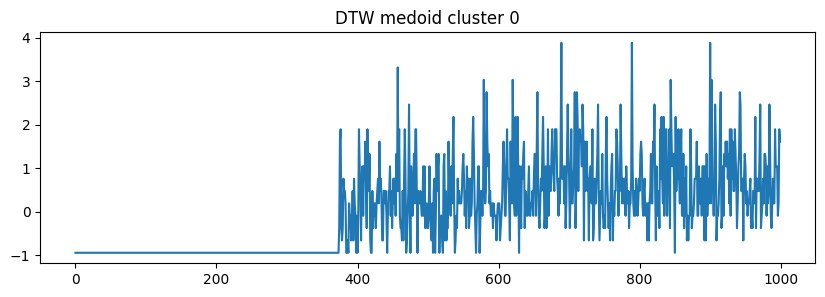

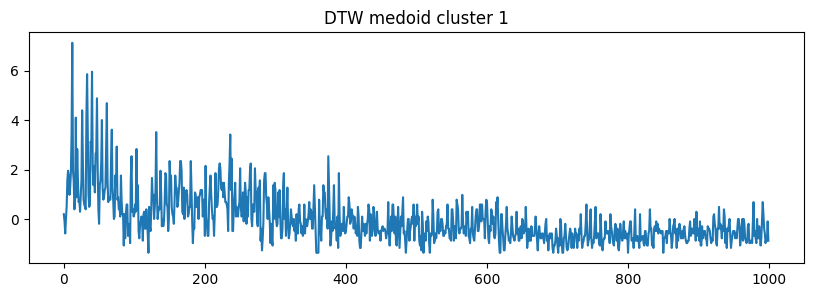

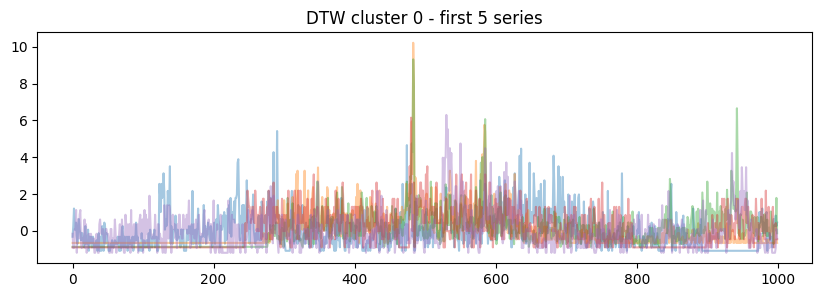

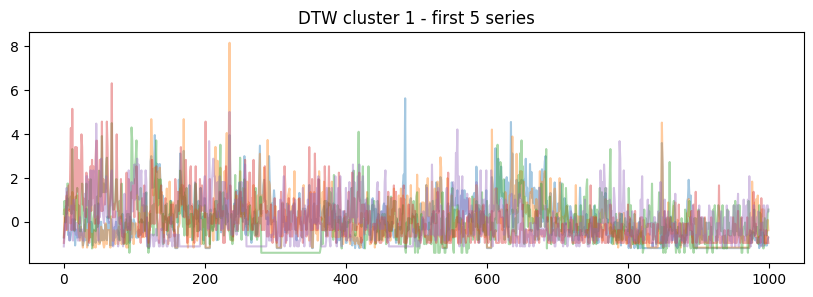

In [398]:
def plot_cluster_examples(X_ts, labels, cluster_id, n_examples=5):
    idx = np.where(labels == cluster_id)[0]
    plt.figure(figsize=(10, 3))
    for i in idx[:n_examples]:
        plt.plot(X_ts[i, :, 0], alpha=0.4)
    plt.title(f"DTW cluster {cluster_id} - first {n_examples} series")
    plt.show()

# Plot medoids
for c in [0, 1]:
    plt.figure(figsize=(10, 3))
    plt.plot(medoids[c, :, 0])
    plt.title(f"DTW medoid cluster {c}")
    plt.show()

# Plot 5 series trong mỗi cluster
plot_cluster_examples(X_ts, shape_labels, cluster_id=0)
plot_cluster_examples(X_ts, shape_labels, cluster_id=1)

In [399]:
feature_cols = ["trend_strength", "acf1", "acf_seasonal", "spectral_entropy"]
# Map DTW labels về feature dataframe
dtw_df = l3_df.loc[cluster_series_ids].copy()
dtw_df["dtw_cluster"] = shape_labels

# Mean profile
display(
    dtw_df.groupby("dtw_cluster")[feature_cols].mean()
)

# Std (dispersion)
display(
    dtw_df.groupby("dtw_cluster")[feature_cols].std()
)

,trend_strength,acf1,acf_seasonal,spectral_entropy
dtw_cluster,,,,
0,1.766273,1.509107,1.716549,-1.863422
1,1.295951,1.365455,1.363343,-1.279495


,trend_strength,acf1,acf_seasonal,spectral_entropy
dtw_cluster,,,,
0,0.847802,0.584193,0.670667,1.151721
1,0.433841,0.467226,0.569688,0.744824


In [400]:
def first_change_point(ts, threshold=0.3):
    diff = np.abs(np.diff(ts))
    idx = np.where(diff > threshold * diff.max())[0]
    return idx[0] if len(idx) > 0 else None

dtw_df["cp"] = [
    first_change_point(X_ts[i, :, 0])
    for i in range(len(X_ts))
]

display(
    dtw_df.groupby("dtw_cluster")["cp"].describe()
)

,count,mean,std,min,25%,50%,75%,max
dtw_cluster,,,,,,,,
0,34.0,195.323529,217.497575,2.0,13.0,93.5,342.25,734.0
1,33.0,22.424242,46.223662,0.0,3.0,4.0,10.00,201.0


In [401]:
def horizon_variance(ts, h=30):
    return np.var(ts[-h:])

dtw_df["tail_var"] = [
    horizon_variance(X_ts[i, :, 0])
    for i in range(len(X_ts))
]

display(
    dtw_df.groupby("dtw_cluster")["tail_var"].describe()
)

,count,mean,std,min,25%,50%,75%,max
dtw_cluster,,,,,,,,
0,34.0,0.783525,0.876307,1.232595e-32,0.397951,0.522424,0.898003,4.813860
1,33.0,0.326038,0.200977,4.930381e-32,0.161136,0.297569,0.519561,0.692286


DTW-KMedoids chia `struct_cluster_1` thành các nhóm con với khác biệt regime rất rõ ràng và có ý nghĩa:

* Khác biệt lớn về thời điểm regime:

Một nhóm có hoạt động mạnh từ sớm và giảm dần theo thời gian

Một nhóm khác có giai đoạn yên lặng dài trước khi bắt đầu hoạt động

Điều này được xác nhận thông qua sự khác biệt lớn trong thống kê first change-point

* Khác biệt về khả năng dự báo:

Nhóm kích hoạt muộn có độ bất định cao hơn trong tương lai

Nhóm kích hoạt sớm có hành vi ổn định hơn ở horizon dự báo

* Độ đồng nhất nội cụm được cải thiện:

Các cụm con theo DTW có độ phân tán (std) của các feature cấu trúc thấp hơn

Các chuỗi trong mỗi nhóm con nhất quán hơn so với cụm feature ban đầu

**Kết luận:**
DTW giúp phát hiện một chiều regime theo thời gian mà phân cụm theo feature không thể hiện được, và chiều này ảnh hưởng trực tiếp đến chiến lược mô hình hóa và xử lý độ bất định.